# check river's position in chinav22_bio_river.nc

In [45]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from cmocean import cm

In [46]:
path_P='/sugon7/zsm/croco_tools_xmd1204/CROCO_FILES/TWS/'
grid_P=path_P+'chinav2_modified.nc'
riv_P=path_P+'chinav22_bio_river.nc'

path_c='/sugon7/zsm/croco_tools_xmd1204/CROCO_FILES/TWS2/'
grid_c=path_c+'TWS2_L1_grid.nc'

In [47]:
gp=xr.open_dataset(grid_P)
lonp=gp['lon_rho'].values
latp=gp['lat_rho'].values
hp=gp['h'].values
maskp=gp['mask_rho'].values
hp=hp*maskp
hp[hp==0]=np.nan

gp

<xarray.Dataset> Size: 180MB
Dimensions:    (one: 1, eta_rho: 1224, xi_rho: 612, bath: 4, eta_u: 1224,
                xi_u: 611, eta_v: 1223, xi_v: 612, eta_psi: 1223, xi_psi: 611,
                s_rho: 30, s_w: 31)
Dimensions without coordinates: one, eta_rho, xi_rho, bath, eta_u, xi_u, eta_v,
                                xi_v, eta_psi, xi_psi, s_rho, s_w
Data variables: (12/38)
    xl         (one) float64 8B ...
    el         (one) float64 8B ...
    depthmin   (one) float64 8B ...
    depthmax   (one) float64 8B ...
    spherical  (one) |S1 1B ...
    angle      (eta_rho, xi_rho) float64 6MB ...
    ...         ...
    mask_v     (eta_v, xi_rho) int32 3MB ...
    mask_psi   (eta_psi, xi_psi) int32 3MB ...
    sigma_r    (s_rho) float64 240B ...
    Cs_r       (s_rho) float64 240B ...
    sigma_w    (s_w) float64 248B ...
    Cs_w       (s_w) float64 248B ...
Attributes:
    title:       /home/jyw/etopo/Depthmaking2016/ncinterp2mif/Grid_Tgood_Fine...
    date:        12-Mar-2019
    type:        CROCO grid file from delft3D
    center_lon:  120.0
    center_lat:  30.0
    rot:         0
    theta_s:     7.0
    theta_b:     2.0
    hc:          200.0
    N:           30

In [48]:
gr=xr.open_dataset(riv_P)
eta_num=gr['river_Eposition'].values.astype(int)
xi_num=gr['river_Xposition'].values.astype(int)

gr

/tmp/ipykernel_3067883/269031429.py:1: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  gr=xr.open_dataset(riv_P)


<xarray.Dataset> Size: 4MB
Dimensions:          (river: 87, river_time: 12, s_rho: 30)
Coordinates:
  * river            (river) float64 696B 1.0 2.0 3.0 4.0 ... 85.0 86.0 87.0
  * river_time       (river_time) timedelta64[ns] 96B 15 days 05:15:00 ... 35...
Dimensions without coordinates: s_rho
Data variables: (12/20)
    river_Xposition  (river) float64 696B 31.0 31.0 31.0 ... 212.0 137.0 118.0
    river_Eposition  (river) float64 696B 1.129e+03 1.128e+03 ... 576.0 625.0
    river_direction  (river) float64 696B ...
    river_Vshape     (s_rho, river) float64 21kB ...
    river_transport  (river_time, river) float64 8kB ...
    river_flag       (river) float64 696B ...
    ...               ...
    river_SDeC       (river_time, s_rho, river) float64 251kB ...
    river_LDeC       (river_time, s_rho, river) float64 251kB ...
    river_TIC        (river_time, s_rho, river) float64 251kB ...
    river_NH4        (river_time, s_rho, river) float64 251kB ...
    river_Oxygen     (river_time, s_rho, river) float64 251kB ...
    river_TALK       (river_time, s_rho, river) float64 251kB ...

In [13]:
eta_num

array([1129, 1128, 1127,  888,  887,  886, 1109, 1179, 1170,  735,  647,
        649,  537,  538,  583,  675,  676,  672,  718,  486,  613,  503,
        463,  144,  143,  143,  142,  141,  462,  191,  123,  195,  116,
        325,  323,  324,  256,  970,  337,  338,  339,  340,  341,  342,
        147,    6,  357,  108,  292,  284,    5,  498,  128,  314,  111,
        347,  439,  455,  584,   47,  127,   70,  166,  611,  321,  643,
        621,  560,  631,  972, 1044,  987,  930,  925,  436,  959,  878,
        977,  938,  914,  901,  952,  929, 1028,  949,  576,  625])

In [23]:
gc=xr.open_dataset(grid_c)
lonc=gc['lon_rho'].values
latc=gc['lat_rho'].values
maskrc=gc['mask_rho'].values.astype(int)


In [15]:

def find_points_in_range(lonp_2d, latp_2d, eta_num_1d, xi_num_1d, lon_min, lon_max, lat_min, lat_max):
    """
    根据 1D 索引数组 (eta_num, xi_num) 在 2D 坐标场中查找点。
    
    参数:
    ----------
    lonp_2d : np.ndarray
        2D 经度场 (eta_rho, xi_rho) -> (1224, 612)
    latp_2d : np.ndarray
        2D 纬度场 (eta_rho, xi_rho) -> (1224, 612)
    eta_num_1d : np.ndarray
        1D eta (y) 索引数组 -> (87,)
    xi_num_1d : np.ndarray
        1D xi (x) 索引数组 -> (87,)
    lon_min, lon_max : float
        经度范围
    lat_min, lat_max : float
        纬度范围
    
    返回:
    -------
    eta_selected : np.ndarray
        eta_num_1d 中符合条件的原始值
    xi_selected : np.ndarray
        xi_num_1d 中符合条件的原始值
    """
    
    # 1. 确保索引是整数
    eta_idx = eta_num_1d.astype(int)
    xi_idx = xi_num_1d.astype(int)
    
    # 2. 使用 1D 索引数组去 2D 坐标场中取值
    # 这是关键：使用 tuple 索引
    point_lons = lonp_2d[eta_idx, xi_idx]
    point_lats = latp_2d[eta_idx, xi_idx]
    
    # 3. 创建布尔掩膜
    mask = (
        (point_lons >= lon_min) & (point_lons <= lon_max) &
        (point_lats >= lat_min) & (point_lats <= lat_max)
    )
    
    # 4. 返回 eta_num, xi_num 中符合条件的原始值
    eta_selected = eta_num_1d[mask]
    xi_selected = xi_num_1d[mask]
    
    return eta_selected, xi_selected

eta_sel, xi_sel = find_points_in_range(
    lonp, latp,           # 1D 坐标
    eta_num, xi_num,       # 2D 索引
    117, 120,             # lon 范围
    24, 26                 # lat 范围
)


/home/zsm/anaconda3/envs/py310_clean/lib/python3.10/site-packages/cartopy/mpl/geoaxes.py:1762: UserWarning: shading value 'guoraud' not in list of valid values ['gouraud', 'nearest', 'flat', 'auto']. Setting shading='auto'.
  result = super().pcolormesh(*args, **kwargs)
/home/zsm/anaconda3/envs/py310_clean/lib/python3.10/site-packages/cartopy/mpl/geoaxes.py:1762: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  result = super().pcolormesh(*args, **kwargs)


(20.0, 30.0)

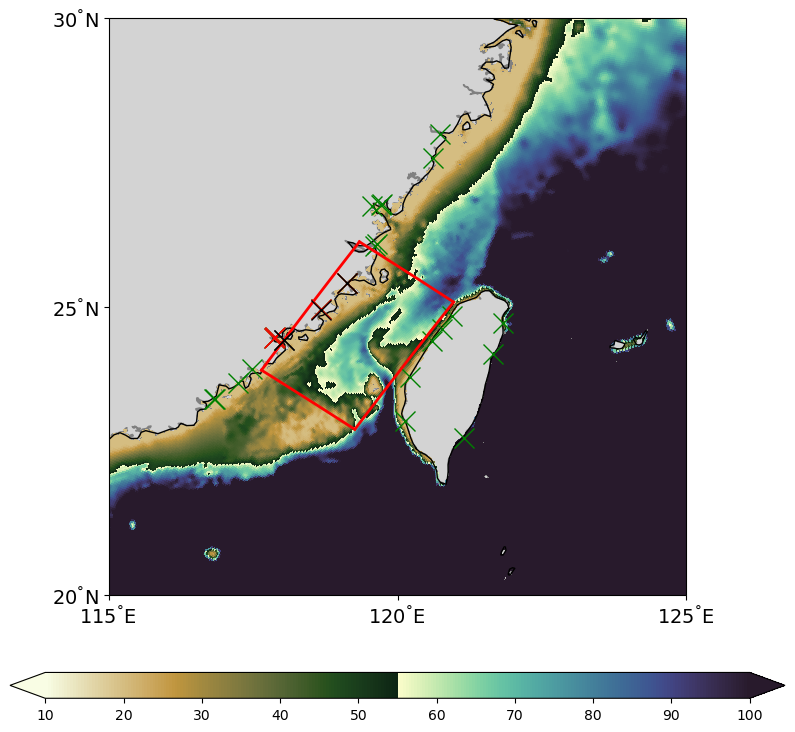

In [26]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.mpl.geoaxes  
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter  # 新导入路径
import matplotlib.ticker as mticker
from cartopy.mpl.geoaxes import GeoAxes

fig2,ax2=plt.subplots(1,1,figsize=(10,10), subplot_kw={'projection': ccrs.PlateCarree()})
ax2.set_facecolor('grey')

cr1=ax2.pcolormesh(lonp,latp,hp,shading='guoraud',cmap=cm.topo_r,vmin=10,vmax=100)
cbar = plt.colorbar(cr1, ax=ax2, orientation='horizontal', pad=0.1, aspect=30, shrink=1,extend='both')

ax2.coastlines(resolution='50m')
ax2.add_feature(cfeature.LAND, edgecolor='gray', facecolor='lightgray')
ax2.plot(lonp[eta_num,xi_num],latp[eta_num,xi_num],linestyle='none',marker='x',markersize=15,color='g')
ax2.plot(lonp[eta_sel,xi_sel],latp[eta_sel,xi_sel],linestyle='none',marker='x',markersize=15,color='r')


ax2.plot(lonc[0,:],latc[0,:],linewidth=2,linestyle='-',color='r')
ax2.plot(lonc[-1,:],latc[-1,:],linewidth=2,linestyle='-',color='r')
ax2.plot(lonc[:,0],latc[:,0],linewidth=2,linestyle='-',color='r')
ax2.plot(lonc[:,-1],latc[:,-1],linewidth=2,linestyle='-',color='r')

ax2.plot(lonc[eta_river,xi_river],latc[eta_river,xi_river],linestyle='none',marker='x',markersize=15,color='k')


ax2.set_xticks(np.array((110,115, 120,125, 130)))  # 设置 x 轴刻度
ax2.set_yticks(np.array((10, 15,20,25, 30)))  # 设置 y 轴刻度
ax2.xaxis.set_tick_params(labelsize=14)  # 设置 x 轴刻度字体大小
ax2.yaxis.set_tick_params(labelsize=14)  # 设置 y 轴刻度字体大小
ax2.set_xticklabels([f"${x}^{{\\degree}}$E " for x in [110,115, 120,125, 130]])
ax2.set_yticklabels([f"${y}^{{\\degree}}$N" for y in [10,15, 20, 25,30]])
ax2.set_xlim([115,125])
ax2.set_ylim([20,30])

In [78]:
eta_sel

array([537, 538, 583, 613])

In [36]:
# a=gr['river_transport'].values[:,[12,13,14,20]]
# a.shape

(12, 4)

In [17]:
eta_sel,xi_sel

# gr['river_Eposition']
# gr['river_Xposition']
# gr['river_direction']
# gr['river_transport']
# gr['river_time']

# gr['river_LDeC']
# gr['river_LDeN']
# gr['river_NH4'] 5
# gr['river_NO3'] 65
# gr['river_Oxygen']
# gr['river_Phyto']
# gr['river_SDeC'] 100
# gr['river_SDeN'] 5
# gr['river_TALK']
# gr['river_TIC'] 300
# gr['river_Vshape']
# gr['river_Zoop']
# gr['river_Chla']


(array([537, 538, 583, 613]), array([ 5,  5, 13, 15]))

In [20]:
river_Xposition=gr['river_Xposition'].values.astype(int)
river_Eposition=gr['river_Eposition'].values.astype(int)

def find_river_indices(xi_pos, eta_pos, xi_sel, eta_sel):
    """
    找到河流索引，使得河流位置等于选中的网格点
    """
    river_indices = []
    
    for xi, eta in zip(xi_sel, eta_sel):
        # 查找同时满足 xi 和 eta 的河流
        idx = np.where((xi_pos == xi) & (eta_pos == eta))[0]
        
        if len(idx) > 0:
            river_indices.append(idx[0])  # 取第一个匹配的河流
        else:
            river_indices.append(None)  # 没找到
    
    return river_indices

# 执行查找
river_idx = find_river_indices(
    river_Xposition, 
    river_Eposition, 
    xi_sel, 
    eta_sel
)

print("河流索引:", river_idx)

河流索引: [np.int64(12), np.int64(13), np.int64(14), np.int64(20)]


In [37]:
a=gr['river_transport'].values[:,[12,13,14,20]]
a.shape

(12, 4)

In [58]:
xi_num.shape

(87,)

# find pos river in child grd

In [27]:
import numpy as np
from scipy.spatial import KDTree

def find_river_positions_on_grid(
    lonp, latp,           # ρ 点坐标 (eta_rho, xi_rho)
    lonc, latc,           # 网格中心坐标 (eta_rho, xi_rho)
    maskrc,                # 水陆掩膜 (eta_rho, xi_rho)
    eta_isel, xi_isel      # 河流在 ρ 点的索引 (n_rivers,)
):
    """
    将河流位置（ρ 点）映射到最近的网格中心水点（maskrc=1）
    
    返回：
        eta_river, xi_river : 河流在网格中心的索引
    """
    
    # 1. 构建“候选水点”的坐标列表
    # 只选取 maskrc == 1 的点
    water_mask = maskrc == 1
    
    # 提取水点的坐标
    lonc_water = lonc[water_mask]
    latc_water = latc[water_mask]
    
    # 将 (lon, lat) 堆叠成 (N, 2) 的数组
    points_water = np.column_stack((lonc_water.ravel(), latc_water.ravel()))
    
    # 2. 构建 KDTree（快速最近邻搜索）
    tree = KDTree(points_water)
    
    # 3. 准备河流查询点
    # 河流在 ρ 点的位置
    river_lon = lonp[eta_isel, xi_isel]
    river_lat = latp[eta_isel, xi_isel]
    
    river_points = np.column_stack((river_lon, river_lat))
    
    # 4. 查询最近的水点
    distances, indices = tree.query(river_points, k=1)
    
    # 5. 将索引映射回网格坐标 (eta, xi)
    # 首先获取水点在原网格中的索引
    eta_water, xi_water = np.where(water_mask)
    
    # 根据 KDTree 返回的索引，找到对应的 eta, xi
    eta_river = eta_water[indices]
    xi_river = xi_water[indices]
    
    return eta_river, xi_river


# ===================== 使用示例 =====================
# 假设你已经加载了以下数据：
# lonp, latp, lonc, latc, maskrc
# eta_isel, xi_isel

eta_river, xi_river = find_river_positions_on_grid(
    lonp, latp,
    lonc, latc,
    maskrc,
    eta_sel, xi_sel
)

print("河流在网格中心的索引：")
print("eta:", eta_river)
print("xi: ", xi_river)

河流在网格中心的索引：
eta: [401 401 362 346]
xi:  [139 139 309 448]


In [49]:
import netCDF4 as nc
import numpy as np
import os

def create_bio_river_template(output_path, n_rivers=21, n_s_rho=50, n_river_time=93):
    """
    创建包含 Fennel 生物模块的 ROMS 河流强迫文件模板。
    """
    
    if os.path.exists(output_path):
        os.remove(output_path)
    
    ds = nc.Dataset(output_path, 'w', format='NETCDF4')
    
    # ===== 全局属性 =====
    ds.title = "ROMS River Forcing Template with Biology"
    ds.type = "ROMS RIVER FORCING file"
    ds.grd_file = "grid.nc"
    ds.history = "Created by Python script in Jupyter"
    
    # ===== 维度 =====
    ds.createDimension('river', n_rivers)
    ds.createDimension('s_rho', n_s_rho)
    ds.createDimension('river_time', n_river_time)
    
    # ===== 基础变量 =====
    # river ID
    river = ds.createVariable('river', 'i4', ('river',))
    river.long_name = "river runoff identification number"
    river.units = "nondimensional"
    river.field = "river, scalar"
    
    # X/Y 位置
    river_Xposition = ds.createVariable('river_Xposition', 'f8', ('river',))
    river_Xposition.long_name = "river XI-position at RHO-points"
    river_Xposition.units = "nondimensional"
    river_Xposition.field = "river_Xposition, scalar"
    
    river_Eposition = ds.createVariable('river_Eposition', 'f8', ('river',))
    river_Eposition.long_name = "river ETA-position at RHO-points"
    river_Eposition.units = "nondimensional"
    river_Eposition.field = "river_Eposition, scalar"
    
    # 方向
    river_direction = ds.createVariable('river_direction', 'f8', ('river',))
    river_direction.long_name = "river runoff direction, XI=0, ETA>0"
    river_direction.units = "nondimensional"
    river_direction.field = "river_direction, scalar"
    
    # 垂向形状
    river_Vshape = ds.createVariable('river_Vshape', 'f8', ('s_rho', 'river'))
    river_Vshape.long_name = "river runoff mass transport vertical profile"
    river_Vshape.units = "nondimensional"
    river_Vshape.field = "river_Vshape, scalar"
    
    # 时间
    river_time = ds.createVariable('river_time', 'f8', ('river_time',))
    river_time.long_name = "river_time climatology" ;
    river_time.units = "days" ;
    river_time.cycle_length = 365.25 ;
    river_time.field = "river_time, scalar, series" ;

    
    # 流量
    river_transport = ds.createVariable('river_transport', 'f8', ('river_time', 'river'))
    river_transport.long_name = "river runoff vertically integrated mass transport"
    river_transport.units = "meter3 second-1"
    river_transport.field = "river_transport, scalar, series"
    river_transport.time = "river_time"
    
    # 温度
    river_temp = ds.createVariable('river_temp', 'f8', ('river_time', 's_rho', 'river'))
    river_temp.long_name = "river runoff potential temperature"
    river_temp.units = "Celsius"
    river_temp.field = "river_temp, scalar, series"
    river_temp.time = "river_time"
    
    # 盐度
    river_salt = ds.createVariable('river_salt', 'f8', ('river_time', 's_rho', 'river'))
    river_salt.long_name = "river runoff salinity"
    river_salt.units = "PSU"
    river_salt.field = "river_salt, scalar, series"
    river_salt.time = "river_time"
    
    # ===== 生物变量（Fennel 模型）=====
    # NO3
    river_NO3 = ds.createVariable('river_NO3', 'f8', ('river_time', 's_rho', 'river'))
    river_NO3.long_name = "river runoff NO3"
    river_NO3.units = "millimole_nitrogen meter-3"
    river_NO3.field = "river NO3, scalar, series"
    river_NO3.time = "river_time"
    
    # Phytoplankton
    river_Phyto = ds.createVariable('river_Phyto', 'f8', ('river_time', 's_rho', 'river'))
    river_Phyto.long_name = "river runoff phytoplankton"
    river_Phyto.units = "millimole_nitrogen meter-3"
    river_Phyto.field = "river phytoplankton, scalar, series"
    river_Phyto.time = "river_time"
    
    # Zooplankton
    river_Zoop = ds.createVariable('river_Zoop', 'f8', ('river_time', 's_rho', 'river'))
    river_Zoop.long_name = "river runoff zooplankton"
    river_Zoop.units = "millimole_nitrogen meter-3"
    river_Zoop.field = "river zooplankton, scalar, series"
    river_Zoop.time = "river_time"
    
    # Chlorophyll-a (Chla)
    river_Chla = ds.createVariable('river_Chla', 'f8', ('river_time', 's_rho', 'river'))
    river_Chla.long_name = "river runoff chlorophyll"
    river_Chla.units = "millimole_carbon meter-3"
    river_Chla.field = "river chlorophyll-C, scalar, series"
    river_Chla.time = "river_time"
    
    # Small Detritus N
    river_SDeN = ds.createVariable('river_SDeN', 'f8', ('river_time', 's_rho', 'river'))
    river_SDeN.long_name = "river runoff small detritus N"
    river_SDeN.units = "millimole_nitrogen meter-3"
    river_SDeN.field = "river small detritus-N, scalar, series"
    river_SDeN.time = "river_time"
    
    # Large Detritus N
    river_LDeN = ds.createVariable('river_LDeN', 'f8', ('river_time', 's_rho', 'river'))
    river_LDeN.long_name = "river runoff large detritus N"
    river_LDeN.units = "millimole_nitrogen meter-3"
    river_LDeN.field = "river large detritus-N, scalar, series"
    river_LDeN.time = "river_time"
    
    # Small Detritus C
    river_SDeC = ds.createVariable('river_SDeC', 'f8', ('river_time', 's_rho', 'river'))
    river_SDeC.long_name = "river runoff small detritus C"
    river_SDeC.units = "millimole_carbon meter-3"
    river_SDeC.field = "river small detritus-C, scalar, series"
    river_SDeC.time = "river_time"
    
    # Large Detritus C
    river_LDeC = ds.createVariable('river_LDeC', 'f8', ('river_time', 's_rho', 'river'))
    river_LDeC.long_name = "river runoff large detritus C"
    river_LDeC.units = "millimole_carbon meter-3"
    river_LDeC.field = "river large detritus-C, scalar, series"
    river_LDeC.time = "river_time"
    
    # TIC (Total Inorganic Carbon)
    river_TIC = ds.createVariable('river_TIC', 'f8', ('river_time', 's_rho', 'river'))
    river_TIC.long_name = "river runoff TIC"
    river_TIC.units = "millimole_carbon meter-3"
    river_TIC.field = "river TIC, scalar, series"
    river_TIC.time = "river_time"
    
    # NH4
    river_NH4 = ds.createVariable('river_NH4', 'f8', ('river_time', 's_rho', 'river'))
    river_NH4.long_name = "river runoff NH4"
    river_NH4.units = "millimole_nitrogen meter-3"
    river_NH4.field = "river NH4, scalar, series"
    river_NH4.time = "river_time"
    
    # Oxygen
    river_Oxygen = ds.createVariable('river_Oxygen', 'f8', ('river_time', 's_rho', 'river'))
    river_Oxygen.long_name = "river runoff O2"
    river_Oxygen.units = "millimole_oxygen meter-3"
    river_Oxygen.field = "river O2, scalar, series"
    river_Oxygen.time = "river_time"
    
    # TALK (Total Alkalinity)
    river_TALK = ds.createVariable('river_TALK', 'f8', ('river_time', 's_rho', 'river'))
    river_TALK.long_name = "river runoff TALK"
    river_TALK.units = "millimole_nitrogen meter-3" # 注意：TALK单位通常是 meq/m3
    river_TALK.field = "river TALK, scalar, series"
    river_TALK.time = "river_time"
    
    # ===== 初始化数据 =====
    # 基础变量
    river[:] = np.arange(n_rivers)
    river_Xposition[:] = [139,139,309,448]
    river_Eposition[:] = [401,401,362,346]
    river_direction[:] = 1.0
    river_Vshape[:, :] = 1.0 / n_s_rho
    river_time[:] = np.array(
    [15.21875, 45.65625, 76.09375, 106.53125,
     136.96875, 167.40625, 197.84375, 228.28125,
     258.71875, 289.15625, 319.59375, 350.03125],
    dtype=np.float64
)
    river_transport[:, :] = a
    river_temp[:, :, :] = 0.0
    river_salt[:, :, :] = 0.0
    
    # 生物变量（全部初始化为 0）
    river_NO3[:, :, :] = 65.0
    river_Phyto[:, :, :] = 0.0
    river_Zoop[:, :, :] = 0.0
    river_Chla[:, :, :] = 0.0
    river_SDeN[:, :, :] = 5.0
    river_LDeN[:, :, :] = 0.0
    river_SDeC[:, :, :] = 100.0
    river_LDeC[:, :, :] = 0.0
    river_TIC[:, :, :] = 10.0
    river_NH4[:, :, :] = 5.0
    river_Oxygen[:, :, :] = 0.0
    river_TALK[:, :, :] = 0.0
    
    ds.close()
    print(f"✅ 生物河流模板已创建: {output_path}")
    print(f"   河流数: {n_rivers}, 垂向层数: {n_s_rho}, 时间步: {n_river_time}")


# ===================== 使用示例 =====================
if __name__ == "__main__":
    create_bio_river_template(
        output_path='/leader/user/zsm/river_bio_offline.nc',
        n_rivers=4,       # 对应 oil_03_river.nc
        n_s_rho=45,        # 对应 oil_03_river.nc
        n_river_time=12      # 对应 oil_03_river.nc
    )

✅ 生物河流模板已创建: /leader/user/zsm/river_bio_offline.nc
   河流数: 4, 垂向层数: 45, 时间步: 12


In [41]:
# river_time

NameError: name 'river_time' is not defined